[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Two-dimensional frame with thermal gradient loading

## Problem description

Frame with two legs. The top is loaded with a thermal gradient through the depth
of the beam.

Displacements and internal forces are provided in the book, and we can check our
solution against these reference values.

## References

This example is completely solved in the book Matrix Analysis of Structures by
Robert E. Sennett, ISBN 978-1577661436 (Example 3.5).

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


We begin with the standard imports:

In [106]:
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots
from pystran import beam

Define a few constants:
US customary units, inches, pounds, seconds are assumed.


In [107]:
E = 30e6
A = 20
I = 100
CTE = 6.5e-6  # coefficient of thermal expansion
Tbot = 0  # temperature at the bottom of beam 2
Ttop = 70  # temperature at the top of beam 2
depth = 10  # depth of the beam section

The model is created as usual.

In [108]:
m = model.create(2)
freedoms = m["freedoms"]

The locations are in inches.


In [109]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [0.0, -12 * 12.0])
model.add_joint(m, 3, [12 * 7.0, 0.0])

{'jid': 3, 'coordinates': array([84.,  0.])}

Only one of the joints is free, the others are clamped.


In [110]:
model.add_support(m["joints"][2], freedoms.ALL_DOFS)
model.add_support(m["joints"][3], freedoms.ALL_DOFS)

At this point we can visualize the supports. The translation supports are
shown with arrow heads.


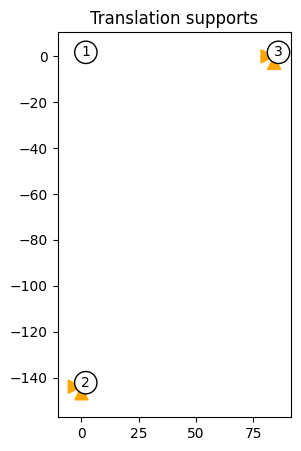

In [111]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.set_title("Translation supports")
plots.show(m)

The rotation supports are shown next.


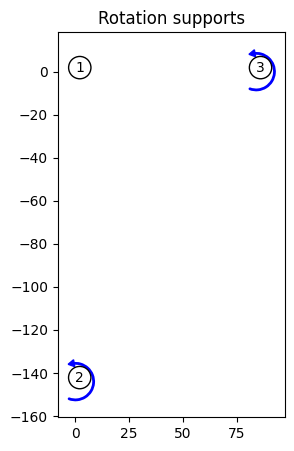

In [112]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_rotation_supports(m, radius=17)
ax.set_title("Rotation supports")
plots.show(m)

There are two beams.


In [113]:
sect_12 = section.beam_2d_section("sect_12", E=E, A=A, I=I)

In [114]:
model.add_beam_member(m, 1, [1, 2], sect_12)
model.add_beam_member(m, 2, [3, 1], sect_12)

{'mid': 2,
 'connectivity': [3, 1],
 'section': {'name': 'sect_12',
  'E': 30000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 20,
  'I': 100}}

This plot shows the orientations of the local coordinate systems of the beams.


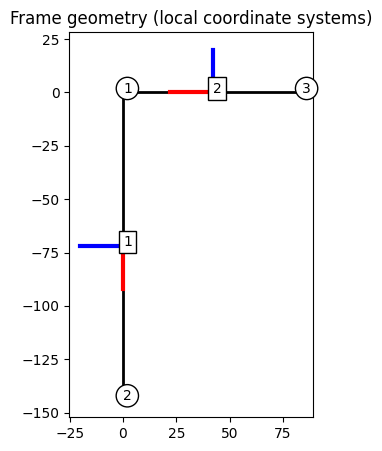

In [115]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_member_orientation(m, 20)
ax.set_title("Frame geometry (local coordinate systems)")
plots.show(m)

Now we consider the thermal  loading.
The two joints of the beam member 2 are:


In [116]:
i, j = [m["joints"][k] for k in m["beam_members"][2]["connectivity"]]

The fixed-end axial forces due to the thermal loading are added to the joints.  The average temperature (the temperature at the neutral axis) leads
to an expansion in length (provided it is positive).


In [117]:
N_T = CTE * (Ttop + Tbot) / 2 * E * A
model.add_load(i, freedoms.U1, +N_T)
model.add_load(j, freedoms.U1, -N_T)

The thermal gradient `(Ttop - Tbot) / depth` generates thermal moments. It is
necessary to consider the local frame orientation in order to apply the
correct sense of the thermal moments. The top surface of the beam is such that
its z-coordinate > z-coordinate of the bottom surface. Therefore the thermal moment


In [118]:

M_T = CTE * (Ttop - Tbot) / depth * E * I
print(f"Thermal moment: {M_T:.2f} kip-in")


Thermal moment: 136500.00 kip-in


is positive. So now the joints are loaded with the thermal moment.


In [119]:
model.add_load(i, freedoms.UR3, -M_T)
model.add_load(j, freedoms.UR3, +M_T)

The nodal moments can be visualized with the following plot.


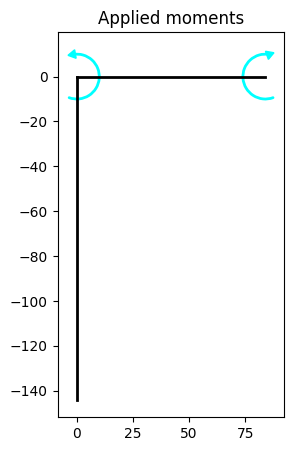

In [138]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_applied_moments(m, 0.0, 20)
ax.set_title("Applied moments")
plots.show(m)

Now we can solve the static equilibrium of the frame.


In [139]:
model.number_dofs(m)
model.solve_statics(m)

The solution to the problem can be visualized with a number of plots. We start
with the deformed shape of the frame.


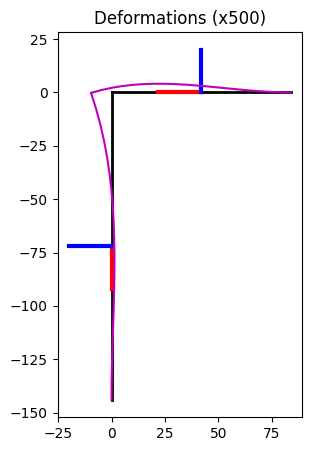

In [140]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_deformations(m, 500.0)
ax.set_title("Deformations (x500)")
plots.show(m)

The displacements of the joints can be printed out. Recall that joints 3 and 2
are clamped, and their displacements are therefore zero.


In [141]:
for jid in [1]:
    j = m["joints"][jid]
    print(jid, j["displacements"])

1 [-0.0191605  -0.00041134  0.00068165]


These are the displacements of joint 1 consistent with the referenced book:


In [142]:

ref1 = [-0.0191605, -0.00041134, 0.00068165]
if norm(m["joints"][1]["displacements"] / ref1 - 1) > 1.0e-3:
    raise ValueError("Displacement calculation error")

The forces in the member with the thermal loading included can be calculated
using the `beam_2d_end_forces` function and then adding the thermal moment and
force. According to the reference, the combined resultants should be at joint
3 (clamped) 360 (axial), 1710 (shear), and -184000 (bending moment), and -360
(axial), -1710 (shear), and 40171 (bending moment).


In [143]:
member = m["beam_members"][2]
connectivity = member["connectivity"]
i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
f = beam.beam_2d_end_forces(member, i, j)
print("Member 2 end forces at joint 3: ", f)
if abs((f["Ni"] + (-N_T)) / 360 - 1) > 1e-2:
    raise ValueError("Member 2, joint i, axial force error")
if abs((f["Qzi"] - 1710) / 1710) > 1e-2:
    raise ValueError("Member 2, joint i, shear force error")
if abs((f["Myi"] - M_T) / -184000 - 1) > 1e-2:
    raise ValueError("Member 2, joint i, bending moment error")
print("Member 2 end forces at joint 1: ", f)
if abs((f["Nj"] - (-N_T)) / -360 - 1) > 1e-2:
    raise ValueError("Member 2, joint i, axial force error")
if abs((f["Qzj"] + 1710) / 1710) > 1e-2:
    raise ValueError("Member 2, joint i, shear force error")
if abs((f["Myj"] + M_T) / 40171 - 1) > 1e-2:
    raise ValueError("Member 2, joint i, bending moment error")

Member 2 end forces at joint 3:  {'Ni': np.float64(136860.70088185635), 'Qzi': np.float64(1713.9073698768323), 'Myi': np.float64(-47639.62934229073), 'Nj': np.float64(-136860.70088185635), 'Qzj': np.float64(-1713.9073698768323), 'Myj': np.float64(-96328.5897273632)}
Member 2 end forces at joint 1:  {'Ni': np.float64(136860.70088185635), 'Qzi': np.float64(1713.9073698768323), 'Myi': np.float64(-47639.62934229073), 'Nj': np.float64(-136860.70088185635), 'Qzj': np.float64(-1713.9073698768323), 'Myj': np.float64(-96328.5897273632)}


The diagrams below are for the discrete model that is loaded with the
negative reactions at the fixed joints. These resultants are not combined with
the thermal forces, they represent the response of the frame with the nodal loads.

The shear forces in the members can be visualized with diagrams.


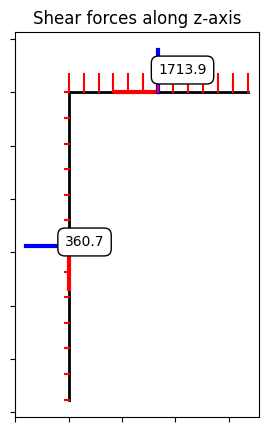

In [144]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_shear_forces(m, scale=0.0050)
ax.set_title("Shear forces along z-axis")
plots.show(m)

The bending moment diagram is shown next.


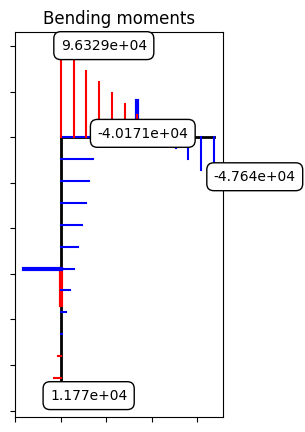

In [145]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_bending_moments(m, scale=0.0005)
ax.set_title("Bending moments")
plots.show(m)

Finally, the axial forces in the members are shown.


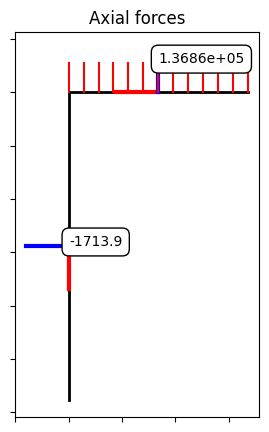

In [147]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m, 20)
ax = plots.plot_axial_forces(m, scale=0.0001)
ax.set_title("Axial forces")
plots.show(m)

To make the internal resultant diagrams complete, we would  need to add in  the internal resultants due to the thermal loading under fixed-end conditions.